In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import datetime
from datetime import date, timedelta
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
pio.templates.default = "plotly_white"

from keras.models import Sequential
from keras.layers import Dense, Activation
from keras.layers import Conv2D,MaxPooling2D,Dropout,Flatten,Dense,Activation,BatchNormalization
import tensorflow as tf

from sklearn.model_selection import train_test_split

In [2]:
data=pd.read_csv("C:\\Users\\G.B\\Desktop\\data science\\dataset\\TWTR.csv")

In [3]:
data = data.dropna()

In [4]:
data.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2013-12-09,45.590000,49.840000,45.020000,49.139999,49.139999,17366614
1,2013-12-10,48.900002,52.580002,48.700001,51.990002,51.990002,25792002
2,2013-12-11,52.400002,53.869999,51.000000,52.340000,52.340000,26631535
3,2013-12-12,52.200001,55.869999,50.689999,55.330002,55.330002,23446870
4,2013-12-13,56.200001,59.410000,55.450001,59.000000,59.000000,38979567


In [5]:
data["Date"] = pd.to_datetime(data["Date"], format = '%Y-%m-%d')
data['Year'] = data['Date'].dt.year
data["Month"] = data["Date"].dt.month

In [6]:
data.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Year,Month
0,2013-12-09,45.590000,49.840000,45.020000,49.139999,49.139999,17366614,2013,12
1,2013-12-10,48.900002,52.580002,48.700001,51.990002,51.990002,25792002,2013,12
2,2013-12-11,52.400002,53.869999,51.000000,52.340000,52.340000,26631535,2013,12
3,2013-12-12,52.200001,55.869999,50.689999,55.330002,55.330002,23446870,2013,12
4,2013-12-13,56.200001,59.410000,55.450001,59.000000,59.000000,38979567,2013,12


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2238 entries, 0 to 2237
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       2238 non-null   datetime64[ns]
 1   Open       2238 non-null   float64       
 2   High       2238 non-null   float64       
 3   Low        2238 non-null   float64       
 4   Close      2238 non-null   float64       
 5   Adj Close  2238 non-null   float64       
 6   Volume     2238 non-null   int64         
 7   Year       2238 non-null   int32         
 8   Month      2238 non-null   int32         
dtypes: datetime64[ns](1), float64(5), int32(2), int64(1)
memory usage: 140.0 KB


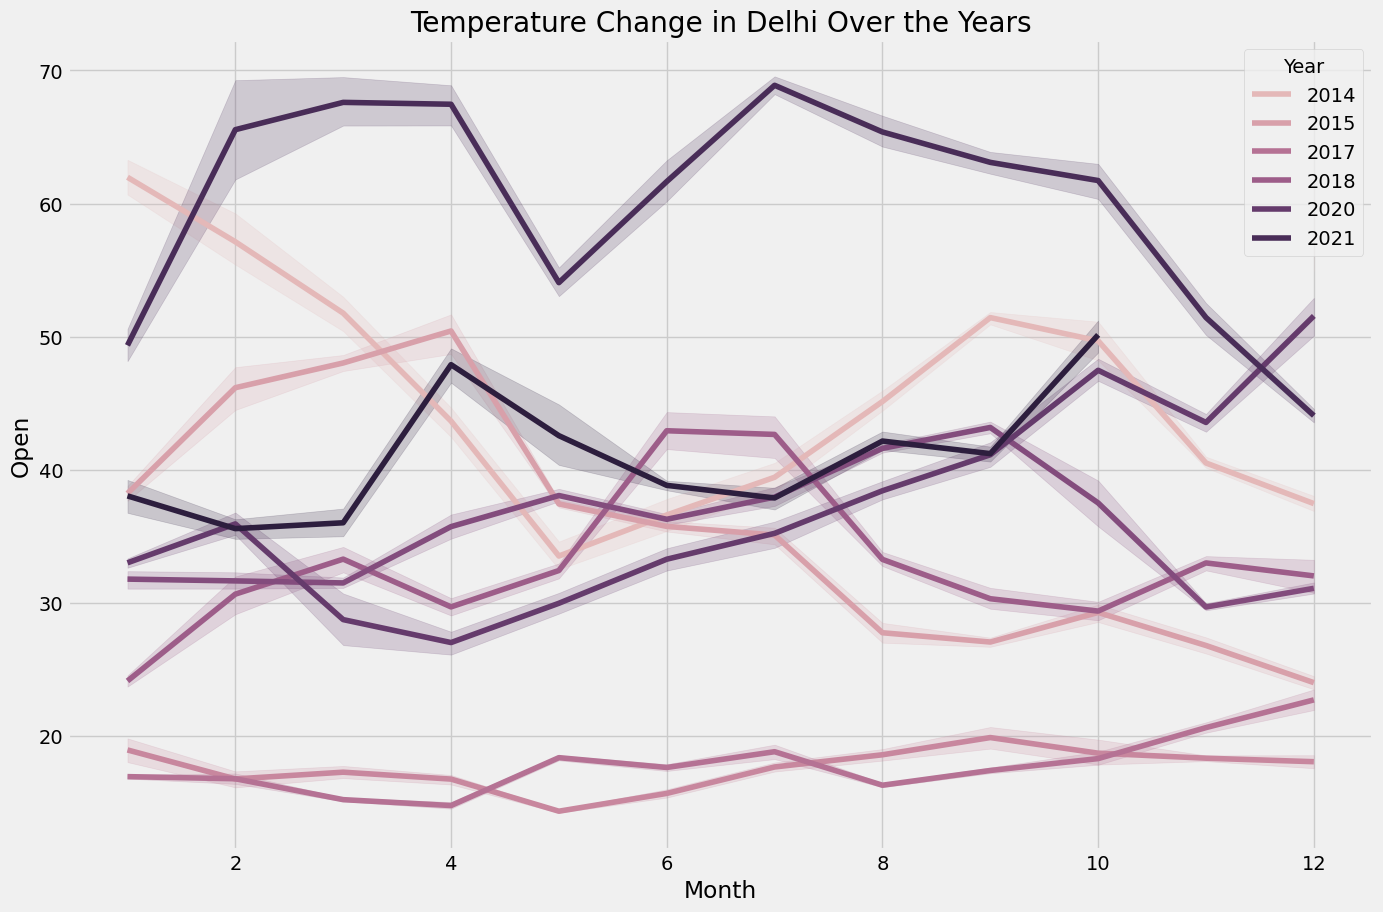

In [8]:
plt.style.use('fivethirtyeight')
plt.figure(figsize=(15, 10))
plt.title("Temperature Change in Delhi Over the Years")
sns.lineplot(data = data, x='Month', y='Open', hue='Year')
plt.show()

In [ ]:
correlation = data.corr()
print(correlation["Close"].sort_values(ascending=False))

In [9]:
from sklearn.model_selection import train_test_split
x = data[["Open", "High", "Low", "Volume"]]
y = data["Close"]

In [10]:

xtrain, xtest, ytrain, ytest = train_test_split(x, y,test_size=0.2, random_state=42)

In [11]:
xtrain

,Open,High,Low,Volume
1269,26.549999,27.270000,26.260000,18208306
1533,32.970001,33.070000,32.490002,11008264
617,14.400000,14.600000,14.330100,12899529
1406,37.369999,37.900002,37.169998,8048674
1134,42.470001,44.330002,42.410000,51154995
...,...,...,...,...
1638,33.939999,34.170101,32.470001,14709354
1095,29.450001,32.056801,29.430000,46696039
1130,39.419998,40.230000,39.209999,147805710
1294,33.070000,33.689999,32.790001,21211309


In [19]:
from keras.models import Sequential
from keras.layers import Dense, LSTM
model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape= 
(xtrain.shape[1], 1)))
model.add(LSTM(64, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))
model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 4, 512)            1052672   
                                                                 
 lstm_1 (LSTM)               (None, 512)               2099200   
                                                                 
 dense_2 (Dense)             (None, 256)               131328    
                                                                 
 dense_3 (Dense)             (None, 256)               65792     
                                                                 
 dense_4 (Dense)             (None, 128)               32896     
                                                                 
 dense_5 (Dense)             (None, 64)                8256      
                                                                 
 dense_6 (Dense)             (None, 32)               

In [ ]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(xtrain, ytrain, batch_size=1, epochs=30)

In [ ]:
model.evaluate(xtrain,ytrain)


In [ ]:
a=model.predict(ytest)


In [ ]:
frame=pd.DataFrame(a,columns=['first'])

In [ ]:
frame

In [ ]:
plt.style.use("bmh")
frame.plot(figsize=(15,5),color="red")
#plt.title(titleplotline)
plt.show()

In [14]:
xtrain.shape[1]

4